Optimization terminated successfully    (Exit mode 0)
            Current function value: 3990.835137381685
            Iterations: 9
            Function evaluations: 277
            Gradient evaluations: 9
Stage 1 Cost: 3990.835137381685
Stage 2 Cost: 55924.41565155537
Stage 3 Cost: 29677.21460944569


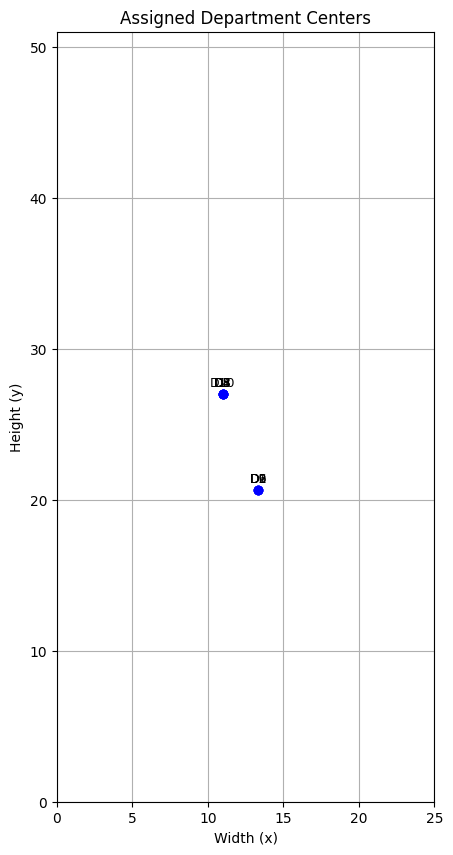

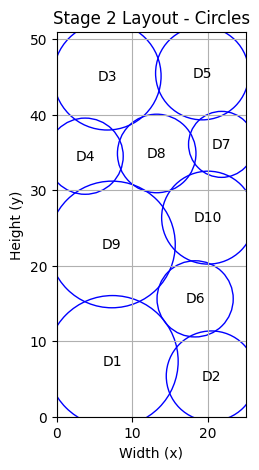

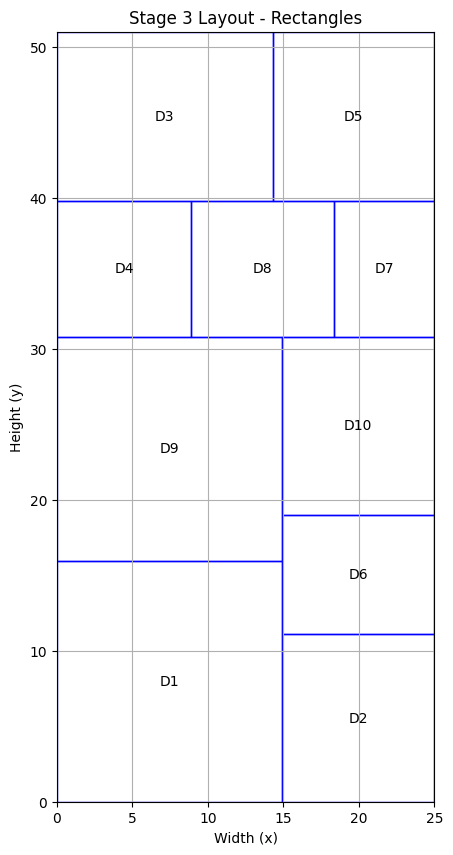

In [ ]:
# path: models/moment_layout_optimizer.py

import numpy as np
import scipy.optimize as opt
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from itertools import combinations


class MomentLayoutOptimizer:
    def __init__(self, n, flow_matrix, cost_vector, facility_width, facility_height):
        self.n = n
        self.flow = flow_matrix
        self.cost = cost_vector
        self.facility_width = facility_width
        self.facility_height = facility_height

    def generate_ideal_layout(self, padding=2.0):
        aspect_ratio = self.facility_width / self.facility_height
        n_cols = int(np.ceil(np.sqrt(self.n * aspect_ratio)))
        n_rows = int(np.ceil(self.n / n_cols))
        x_vals = np.linspace(padding, self.facility_width - padding, n_cols)
        y_vals = np.linspace(padding, self.facility_height - padding, n_rows)
        xv, yv = np.meshgrid(x_vals, y_vals)
        centers = np.column_stack((xv.ravel(), yv.ravel()))
        return centers[:self.n]

    def assign_departments_by_transport_cost(self, initial_centers):
        def objective(x):
            coords = x.reshape(self.n, 2)
            dists = cdist(coords, coords)
            return np.sum(self.flow * dists)

        result = opt.minimize(
            objective,
            initial_centers.flatten(),
            method='L-BFGS-B',
            bounds=[(0, self.facility_width) if i % 2 == 0 else (0, self.facility_height) for i in range(2 * self.n)],
            options={'maxiter': 10000, 'disp': True}
        )

        return result.x.reshape(self.n, 2)


    def get_ideal_moments(self, coords, m=1, N=2):
        coords = coords.reshape(self.n, 2)
        moments = {}
        for order in range(1, N + 1):
            for k in range(0, min(order, m) + 1):
                moments[(order, k)] = np.sum(coords[:, 0] ** (order - k) * coords[:, 1] ** k)
        return moments

    def stage1_objective(self, coords):
        coords = coords.reshape(self.n, 2)
        d2 = np.sum((coords[:, None, :] - coords[None, :, :]) ** 2, axis=2)
        external_d2 = np.sum(coords ** 2, axis=1)
        total_cost = np.sum(self.flow * d2) + np.sum(self.cost * external_d2)
        return total_cost

    def moment_constraints(self, coords, ideal_moments, m=1, N=2):
        coords = coords.reshape(self.n, 2)
        current = self.get_ideal_moments(coords, m, N)
        return [current.get(key, 0) - ideal_moments[key] for key in ideal_moments]

    def solve_stage1_with_moment_constraints(self, initial_coords, ideal_moments, m=1, N=2):
        constraints = {
            'type': 'eq',
            'fun': lambda x: self.moment_constraints(x, ideal_moments, m=m, N=N)
        }
        return opt.minimize(
            self.stage1_objective,
            initial_coords.flatten(),
            constraints=constraints,
            method='SLSQP',
            options={'maxiter': 10000, 'disp': True}
        )

    def stage2_objective(self, coords, radii):
        coords = coords.reshape(self.n, 2)
        d = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=2)
        penalty = 0
        for i in range(self.n):
            for j in range(i + 1, self.n):
                min_dist = radii[i] + radii[j]
                actual_dist = d[i, j]
                if actual_dist < min_dist:
                    penalty += (min_dist - actual_dist) ** 2
        for i in range(self.n):
            x, y, r = coords[i, 0], coords[i, 1], radii[i]
            penalty += max(0, r - x) ** 2
            penalty += max(0, r - y) ** 2
            penalty += max(0, x + r - self.facility_width) ** 2
            penalty += max(0, y + r - self.facility_height) ** 2
            # penalty += max(0, ltmin - radii[i]) ** 2
            # penalty += max(0, radii[i] - ltmax) ** 2
        return np.sum(self.flow * d) + 1e3 * penalty

    def solve_stage2_with_circle_model(self, initial_coords, areas):
        radii = np.sqrt(np.array(areas) / np.pi)
        result = opt.minimize(
            lambda x: self.stage2_objective(x, radii),
            initial_coords.flatten(),
            method='L-BFGS-B',
            options={'maxiter': 10000, 'disp': True}
        )
        return result, radii

    def stage3_objective(self, vars):
        coords = vars[:2*self.n].reshape(self.n, 2)
        widths = vars[2*self.n:3*self.n]
        heights = vars[3*self.n:]
        flow_cost = np.sum(self.flow * cdist(coords, coords))
        penalty_cost = 0
        for i in range(self.n):
            xi, yi = coords[i]
            wi, hi = widths[i], heights[i]
            penalty_cost += max(0, - (xi - wi / 2)) ** 2
            penalty_cost += max(0, - (yi - hi / 2)) ** 2
            penalty_cost += max(0, (xi + wi / 2 - self.facility_width)) ** 2
            penalty_cost += max(0, (yi + hi / 2 - self.facility_height)) ** 2
            for j in range(i + 1, self.n):
                xj, yj = coords[j]
                wj, hj = widths[j], heights[j]
                dx = abs(xi - xj)
                dy = abs(yi - yj)
                wx = 0.5 * (wi + wj)
                hy = 0.5 * (hi + hj)
                if dx < wx and dy < hy:
                    if wx - dx < hy - dy:
                        penalty_cost += (wx - dx) ** 2
                    else:
                        penalty_cost += (hy - dy) ** 2
        return flow_cost + 1e8 * penalty_cost

    def solve_stage3_with_dimension_optimization(self, initial_centers, areas):
        def objective(x):
            coords = x[:2*self.n].reshape(self.n, 2)
            ws = x[2*self.n:3*self.n]
            hs = x[3*self.n:]
            flow_cost = np.sum(self.flow * cdist(coords, coords))
            penalty_cost = 0
            for i in range(self.n):
                xi, yi, wi, hi = coords[i, 0], coords[i, 1], ws[i], hs[i]
                penalty_cost += max(0, - (xi - wi / 2)) ** 2
                penalty_cost += max(0, - (yi - hi / 2)) ** 2
                penalty_cost += max(0, (xi + wi / 2 - self.facility_width)) ** 2
                penalty_cost += max(0, (yi + hi / 2 - self.facility_height)) ** 2
                penalty_cost += (wi * hi - areas[i]) ** 2
                for j in range(i + 1, self.n):
                    xj, yj, wj, hj = coords[j, 0], coords[j, 1], ws[j], hs[j]
                    dx = abs(xi - xj)
                    dy = abs(yi - yj)
                    wx = 0.5 * (wi + wj)
                    hy = 0.5 * (hi + hj)
                    if dx < wx and dy < hy:
                        if wx - dx < hy - dy:
                            penalty_cost += (wx - dx) ** 2
                        else:
                            penalty_cost += (hy - dy) ** 2
            return flow_cost + 1e8 * penalty_cost

        x0 = np.concatenate([
            initial_centers.flatten(),
            np.full(self.n, 10.0),  # Initial width
            np.array([areas[i] / 10.0 for i in range(self.n)])  # Initial height from area/w
        ])

        bounds = [
            (0, self.facility_width) if i % 2 == 0 else (0, self.facility_height)
            for i in range(2 * self.n)  # Bounds for x and y coordinates
              ] + [(5, None)] * (2 * self.n)  # Only minimum bound for widths and heights


        result = opt.minimize(
            objective,
            x0,
            method='L-BFGS-B',
            bounds=bounds,
            options={'maxiter': 10000, 'maxfun': 500000, 'disp': True}
        )
        return result

    def delta_swap_stage1_centers(self, coords, areas, delta=0.1):
        """
        Swap departments with similar areas if it reduces total cost (Stage 1 style).
        """
        coords = coords.copy()
        best_cost = self.stage1_objective(coords.flatten())
        improved = True

        while improved:
            improved = False
            for i, j in combinations(range(self.n), 2):
                ai, aj = areas[i], areas[j]
                if abs(1 - ai / aj) < delta:
                    swapped_coords = coords.copy()
                    swapped_coords[[i, j]] = swapped_coords[[j, i]]
                    cost = self.stage1_objective(swapped_coords.flatten())
                    if cost < best_cost:
                        print(f"Swapping D{i+1} and D{j+1} reduced cost {best_cost:.2f} → {cost:.2f}")
                        coords = swapped_coords
                        best_cost = cost
                        improved = True
                        break  # Optional: restart from scratch after improvement
        return coords


    def plot_department_centers(self, centers, title="Assigned Department Centers"):
        fig, ax = plt.subplots(figsize=(6, 10))
        ax.set_title(title)
        ax.set_xlim(0, self.facility_width)
        ax.set_ylim(0, self.facility_height)
        ax.set_aspect('equal')
        ax.grid(True)

        for i, (x, y) in enumerate(centers):
            ax.plot(x, y, 'bo')  # blue dot for center
            ax.text(x, y + 0.5, f'D{i+1}', ha='center', fontsize=9)

        ax.set_xlabel("Width (x)")
        ax.set_ylabel("Height (y)")
        plt.show()


    def plot_rectangles_variable_size(self, x, title="Stage 3 Layout - Rectangles"):
        coords = x[:2*self.n].reshape(self.n, 2)
        ws = x[2*self.n:3*self.n]
        hs = x[3*self.n:]
        fig, ax = plt.subplots(figsize=(6, 10))
        ax.set_title(title)
        ax.set_xlim(0, self.facility_width)
        ax.set_ylim(0, self.facility_height)
        ax.set_aspect('equal')
        ax.grid(True)
        for i, (x, y) in enumerate(coords):
            w, h = ws[i], hs[i]
            rect = Rectangle((x - w / 2, y - h / 2), w, h, edgecolor='blue', fill=False)
            ax.add_patch(rect)
            ax.text(x, y, f'D{i+1}', ha='center', va='center', fontsize=10)
        ax.set_xlabel("Width (x)")
        ax.set_ylabel("Height (y)")
        plt.show()

    def plot_circles(self, centers, radii, title="Circular Layout"):
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.set_title(title)
        ax.set_xlim(0, self.facility_width)
        ax.set_ylim(0, self.facility_height)
        ax.set_aspect('equal')
        ax.grid(True)
        for i, (x, y) in enumerate(centers):
            ax.add_patch(Circle((x, y), radii[i], edgecolor='blue', fill=False))
            ax.text(x, y, f'D{i+1}', ha='center', va='center')
        ax.set_xlabel("Width (x)")
        ax.set_ylabel("Height (y)")
        plt.show()

if __name__ == "__main__":
    n = 10
    facility_width = 25
    facility_height = 51
    cost_matrix = np.array([
        [0, 0, 0, 0, 0, 218, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 148, 0, 0, 296, 0],
        [0, 0, 0, 28, 70, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 28, 70, 140, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 210, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 28],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 888],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 59.2],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    ])
    cost_vector = np.zeros(n)
    areas = np.array([238, 112, 160, 80, 120, 80, 60, 85, 221, 119])
    ltmin = 25
    ltmax = 25

    optimizer = MomentLayoutOptimizer(n, cost_matrix, cost_vector, facility_width, facility_height)
    ideal_grid = optimizer.generate_ideal_layout()
    assigned_centers = optimizer.assign_departments_by_transport_cost(ideal_grid)
    ideal_moments = optimizer.get_ideal_moments(assigned_centers, m=1, N=4)

    result1 = optimizer.solve_stage1_with_moment_constraints(assigned_centers, ideal_moments, m=1, N=4)
    if not result1.success:
        print("Stage 1 optimization failed", result1.message)
        exit()
    coords1 = result1.x.reshape(n, 2)
    print("Stage 1 Cost:", result1.fun)

    result2, radii = optimizer.solve_stage2_with_circle_model(coords1, areas)
    if not result2.success:
        print("Stage 2 optimization failed", result2.message)
        exit()
    coords2 = result2.x.reshape(n, 2)
    print("Stage 2 Cost:", result2.fun)

    result3 = optimizer.solve_stage3_with_dimension_optimization(coords2, areas)
    if not result3.success:
        print("Stage 3 optimization failed", result3.message)
        exit()
    print("Stage 3 Cost:", result3.fun)

    optimizer.plot_department_centers(assigned_centers)
    optimizer.plot_circles(coords2, radii, title="Stage 2 Layout - Circles")
    optimizer.plot_rectangles_variable_size(result3.x, title="Stage 3 Layout - Rectangles")

[{'n': 10, 'facility_width': 25, 'facility_height': 51, 'cost_matrix': array([[  0. ,   0. ,   0. ,   0. ,   0. , 218. ,   0. ,   0. ,   0. ,
          0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. , 148. ,   0. ,   0. , 296. ,
          0. ],
       [  0. ,   0. ,   0. ,  28. ,  70. ,   0. ,   0. ,   0. ,   0. ,
          0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,  28. ,  70. , 140. ,   0. ,
          0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. , 210. ,   0. ,
          0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
         28. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
        888. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
         59.2],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ]]), 'cost_vector': array([0., 0., 0., 0., 0., 0., 0., 0., 0.,

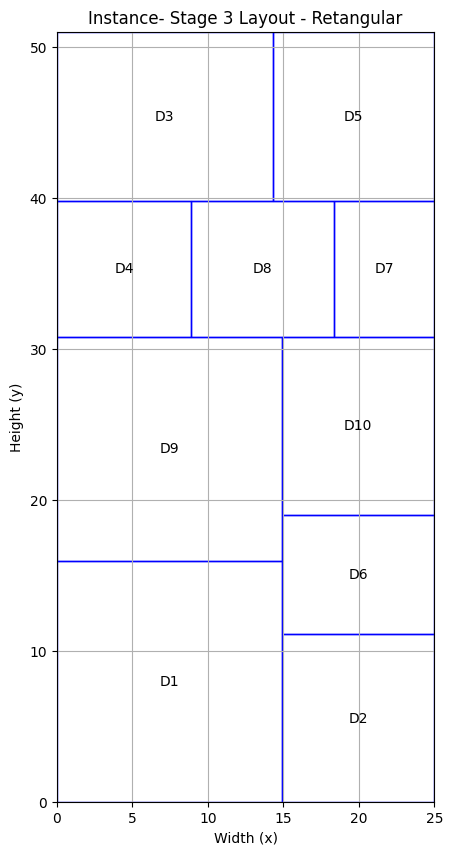


--- Running Instance 2 ---
Singular matrix C in LSQ subproblem    (Exit mode 6)
            Current function value: 248096.63450119487
            Iterations: 1
            Function evaluations: 21
            Gradient evaluations: 1
Instance 2 - Stage 1 Optimization:
  Failed: Singular matrix C in LSQ subproblem

--- Running Instance 3 ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: 186397.2771771165
            Iterations: 1
            Function evaluations: 32
            Gradient evaluations: 1
Instance 3 - Stage 1 Optimization:
  Success: Cost = 186397.28
Instance 3 - Stage 2 Optimization:
  Success: Cost = 364984.90
Instance 3 - Stage 3 Optimization:
  Success: Cost = 312714.43


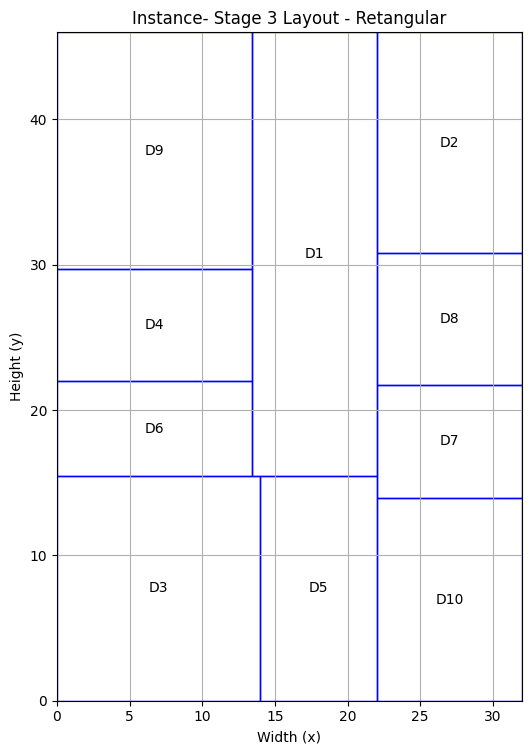


--- Running Instance 4 ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: 492063.3503934964
            Iterations: 1
            Function evaluations: 32
            Gradient evaluations: 1
Instance 4 - Stage 1 Optimization:
  Success: Cost = 492063.35
Instance 4 - Stage 2 Optimization:
  Success: Cost = 544015.63
Instance 4 - Stage 3 Optimization:
  Success: Cost = 405873.36


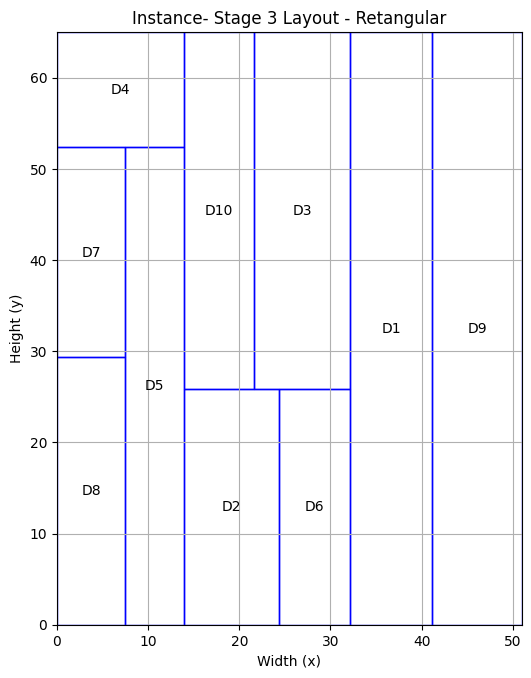


--- Running Instance 5 ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: 303511.20989925286
            Iterations: 1
            Function evaluations: 32
            Gradient evaluations: 1
Instance 5 - Stage 1 Optimization:
  Success: Cost = 303511.21
Instance 5 - Stage 2 Optimization:
  Success: Cost = 415609.14
Instance 5 - Stage 3 Optimization:
  Success: Cost = 50140192.14


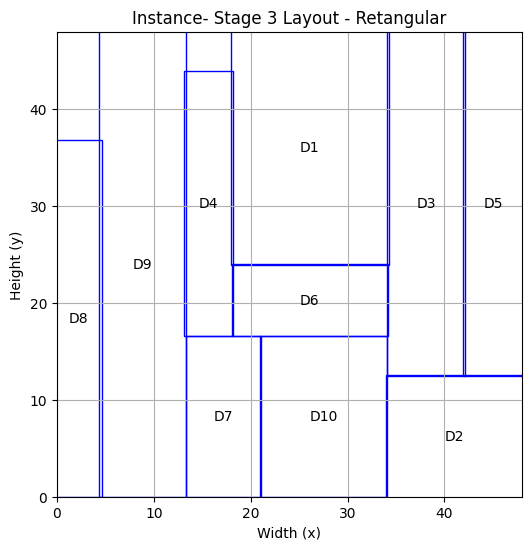


--- Running Instance 6 ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: 232673.30892780778
            Iterations: 7
            Function evaluations: 215
            Gradient evaluations: 7
Instance 6 - Stage 1 Optimization:
  Success: Cost = 232673.31
Instance 6 - Stage 2 Optimization:
  Success: Cost = 398434.29
Instance 6 - Stage 3 Optimization:
  Success: Cost = 345605.25


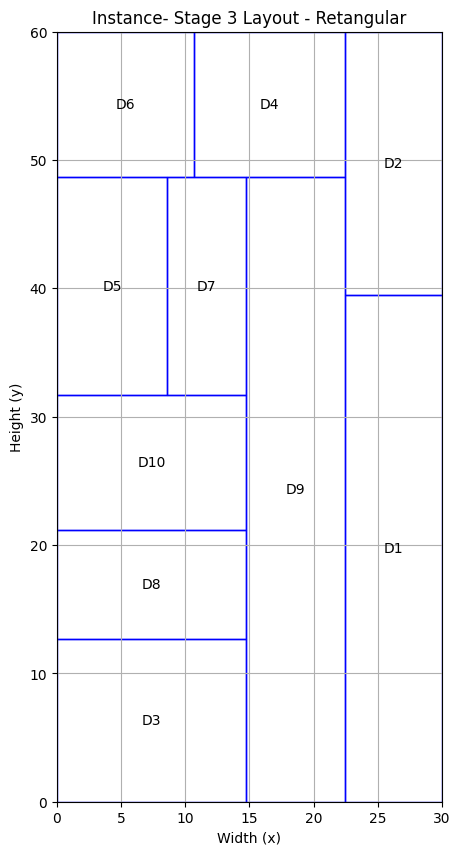


--- Running Instance 7 ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: 490920.9302831553
            Iterations: 1
            Function evaluations: 32
            Gradient evaluations: 1
Instance 7 - Stage 1 Optimization:
  Success: Cost = 490920.93
Instance 7 - Stage 2 Optimization:
  Success: Cost = 535823.71
Instance 7 - Stage 3 Optimization:
  Success: Cost = 88931946.63


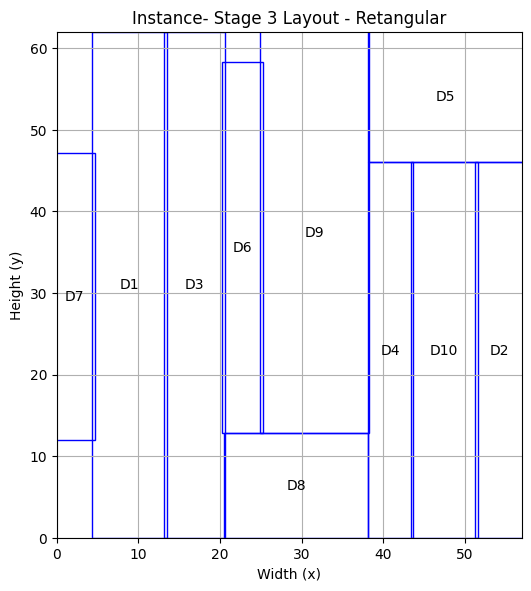


--- Running Instance 8 ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: 233238.81822950274
            Iterations: 1
            Function evaluations: 32
            Gradient evaluations: 1
Instance 8 - Stage 1 Optimization:
  Success: Cost = 233238.82
Instance 8 - Stage 2 Optimization:
  Success: Cost = 421499.01
Instance 8 - Stage 3 Optimization:
  Success: Cost = 414738.56


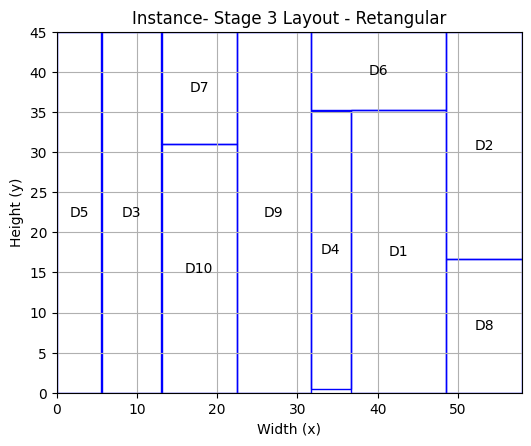


--- Running Instance 9 ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: 177985.47796990236
            Iterations: 31
            Function evaluations: 872
            Gradient evaluations: 31
Instance 9 - Stage 1 Optimization:
  Success: Cost = 177985.48
Instance 9 - Stage 2 Optimization:
  Success: Cost = 303269.55
Instance 9 - Stage 3 Optimization:
  Success: Cost = 103078830.73


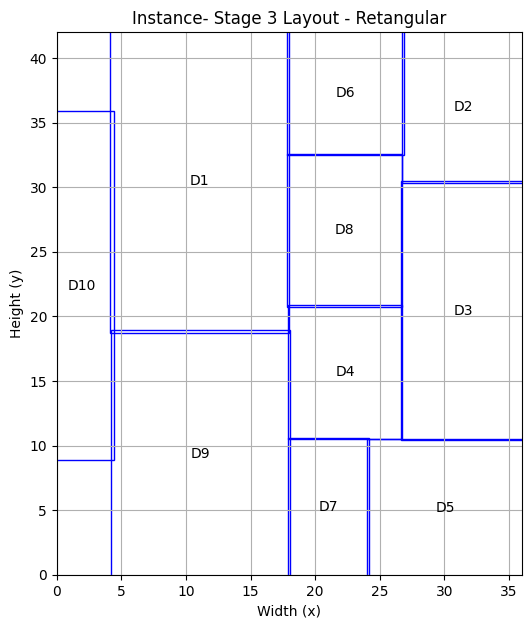


--- Running Instance 10 ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: 180215.42819010987
            Iterations: 1
            Function evaluations: 32
            Gradient evaluations: 1
Instance 10 - Stage 1 Optimization:
  Success: Cost = 180215.43
Instance 10 - Stage 2 Optimization:
  Success: Cost = 292780.81
Instance 10 - Stage 3 Optimization:
  Success: Cost = 28549355.80


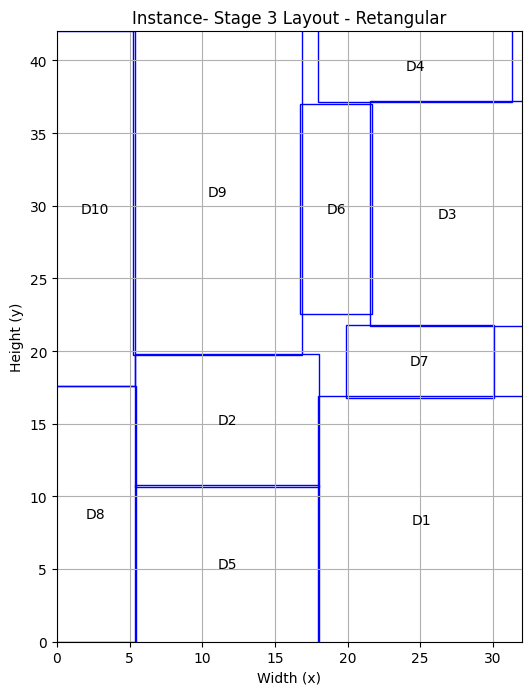

In [ ]:

if __name__ == "__main__":
    np.random.seed(42) # for reproducibility
    facility_area = 25 * 51 # Calculate facility area
    n_original = 10
    original_areas = np.array([238, 112, 160, 80, 120, 80, 60, 85, 221, 119])

    instances = []
    # Instance 1 (provided in the question)
    instances.append({
        'n': 10,
        'facility_width': 25,
        'facility_height': 51,
        'cost_matrix': np.array([
            [0, 0, 0, 0, 0, 218, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 148, 0, 0, 296, 0],
            [0, 0, 0, 28, 70, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 28, 70, 140, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 210, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 28],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 888],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 59.2],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
        ]),
        'cost_vector': np.zeros(10),
        'areas': np.array([238, 112, 160, 80, 120, 80, 60, 85, 221, 119])
    })

    # Generate 9 more similar random instances
    for i in range(9):
        n = n_original
        facility_width = np.random.randint(30, 60)
        facility_height = np.random.randint(40, 70)
        cost_matrix = np.random.randint(0, 300, size=(n, n))
        np.fill_diagonal(cost_matrix, 0)
        # Ensure some non-zero costs similar to the first instance
        for r in range(n):
            for c in range(n):
                if instances[0]['cost_matrix'][r, c] > 0 and np.random.rand() < 0.5:
                    cost_matrix[r, c] = np.random.randint(int(instances[0]['cost_matrix'][r, c] * 0.5), int(instances[0]['cost_matrix'][r, c] * 1.5) + 1)

        cost_vector = np.random.rand(n) * 50
        # Keep areas relatively similar, ensuring the sum equals facility area
        facility_area = facility_width * facility_height
        base_scale = facility_area / np.sum(original_areas)
        areas = original_areas * (0.8 + np.random.rand(n) * 0.4) # Scale around the original areas
        areas = facility_area * areas / np.sum(areas) # Normalize to facility area

        instances.append({
            'n': n,
            'facility_width': facility_width,
            'facility_height': facility_height,
            'cost_matrix': cost_matrix,
            'cost_vector': cost_vector,
            'areas': areas
        })
        print(instances)
    for i, instance in enumerate(instances):
        print(f"\n--- Running Instance {i+1} ---")
        n = instance['n']
        facility_width = instance['facility_width']
        facility_height = instance['facility_height']
        cost_matrix = instance['cost_matrix']
        cost_vector = instance['cost_vector']
        areas = instance['areas']

        optimizer = MomentLayoutOptimizer(n, cost_matrix, cost_vector, facility_width, facility_height)
        ideal_grid = optimizer.generate_ideal_layout()
        assigned_centers = optimizer.assign_departments_by_transport_cost(ideal_grid)
        ideal_moments = optimizer.get_ideal_moments(assigned_centers, m=1, N=4)

        result1 = optimizer.solve_stage1_with_moment_constraints(assigned_centers, ideal_moments, m=1, N=4)
        print(f"Instance {i+1} - Stage 1 Optimization:")
        if not result1.success:
            print(f"  Failed: {result1.message}")
        else:
            print(f"  Success: Cost = {result1.fun:.2f}")
            coords1 = result1.x.reshape(n, 2)

            result2, radii = optimizer.solve_stage2_with_circle_model(coords1, areas)
            print(f"Instance {i+1} - Stage 2 Optimization:")
            if not result2.success:
                print(f"  Failed: {result2.message}")
            else:
                print(f"  Success: Cost = {result2.fun:.2f}")
                coords2 = result2.x.reshape(n, 2)
                # optimizer.plot_circles(coords2, radii, title=f"Instance {i+1} - Stage 2 Layout - Circles")

                result3 = optimizer.solve_stage3_with_dimension_optimization(coords2, areas)
                print(f"Instance {i+1} - Stage 3 Optimization:")
                if not result3.success:
                    print(f"  Failed: {result3.message}")
                else:
                    print(f"  Success: Cost = {result3.fun:.2f}")
                    optimizer.plot_rectangles_variable_size(result3.x, title=f"Instance- Stage 3 Layout - Retangular")

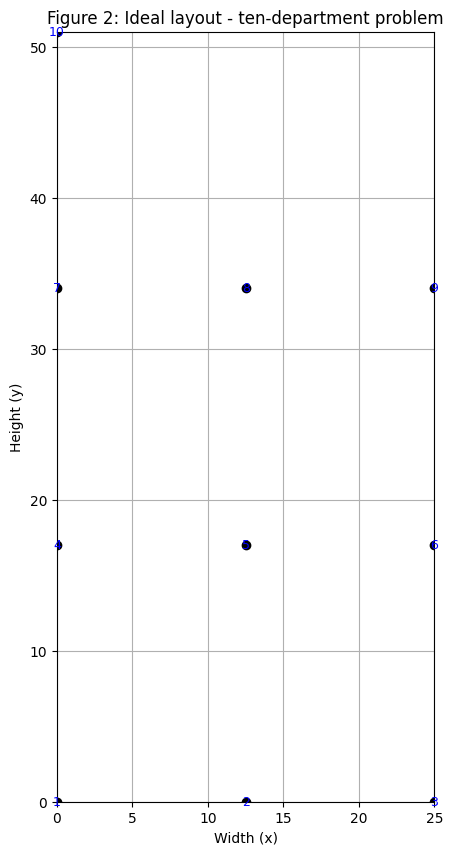

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 21
            Gradient evaluations: 1
Stage 1 optimization result: 0.0


In [ ]:
# path: models/moment_layout_optimizer.py

import numpy as np
import scipy.optimize as opt
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

class MomentLayoutOptimizer:
    def __init__(self, n, flow_matrix, cost_vector, facility_width, facility_height):
        self.n = n
        self.flow = flow_matrix
        self.cost = cost_vector
        self.facility_width = facility_width
        self.facility_height = facility_height

    def generate_ideal_layout(self):
        aspect_ratio = self.facility_width / self.facility_height
        n_cols = int(np.ceil(np.sqrt(self.n * aspect_ratio)))
        n_rows = int(np.ceil(self.n / n_cols))

        x_vals = np.linspace(0, self.facility_width, n_cols)
        y_vals = np.linspace(0, self.facility_height, n_rows)
        xv, yv = np.meshgrid(x_vals, y_vals)
        centers = np.column_stack((xv.ravel(), yv.ravel()))
        return centers[:self.n]

    def stage1_objective(self, coords):
        coords = coords.reshape(self.n, 2)
        d2 = np.sum((coords[:, None, :] - coords[None, :, :]) ** 2, axis=2)
        external_d2 = np.sum(coords ** 2, axis=1)
        total_cost = np.sum(self.flow * d2) + np.sum(self.cost * external_d2)
        return total_cost

    def get_moments(self, coords, m=1, N=2):
        coords = coords.reshape(self.n, 2)
        moments = {}
        for order in range(1, N + 1):
            for k in range(0, order + 1):
                moments[(order, k)] = np.sum(coords[:, 0] ** (order - k) * coords[:, 1] ** k)
        return moments

    def moment_constraints(self, coords, ideal_moments, m=1, N=2):
        coords = coords.reshape(self.n, 2)
        current_moments = self.get_moments(coords, m, N)
        return [current_moments[key] - ideal_moments[key] for key in ideal_moments]

    def solve_stage1(self, initial_coords, m=1, N=4):
        ideal_moments = self.get_moments(initial_coords, m, N)
        constraints = {
            'type': 'eq',
            'fun': lambda x: self.moment_constraints(x, ideal_moments, m, N)
        }
        return opt.minimize(
            self.stage1_objective,
            initial_coords.flatten(),
            constraints=constraints,
            method='SLSQP',
            options={'maxiter': 10000, 'disp': True}
        )

    def plot_centers(self, centers, title="Ideal Layout Centers"):
        fig, ax = plt.subplots(figsize=(6, 10))
        ax.set_title(title)
        ax.set_xlim(0, self.facility_width)
        ax.set_ylim(0, self.facility_height)
        ax.set_aspect('equal')
        ax.grid(True)
        for i, (x, y) in enumerate(centers):
            ax.plot(x, y, 'ko')
            ax.text(x, y, f'{i+1}', ha='center', va='center', fontsize=9, color='blue')
        ax.set_xlabel("Width (x)")
        ax.set_ylabel("Height (y)")
        plt.show()

if __name__ == "__main__":
    n = 10
    facility_width = 25
    facility_height = 51
    cost_matrix = np.zeros((n, n))
    cost_vector = np.zeros(n)

    optimizer = MomentLayoutOptimizer(n, cost_matrix, cost_vector, facility_width, facility_height)
    ideal_centers = optimizer.generate_ideal_layout()
    optimizer.plot_centers(ideal_centers, title="Figure 2: Ideal layout - ten-department problem")

    result = optimizer.solve_stage1(ideal_centers)
    print("Stage 1 optimization result:", result.fun)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 38601.974314287654
            Iterations: 493
            Function evaluations: 11034
            Gradient evaluations: 493
Stage 1 Cost: 38601.974314287654
Stage 2 Cost: 60473.184714770956
Stage 3 Cost: 23742.167826337383


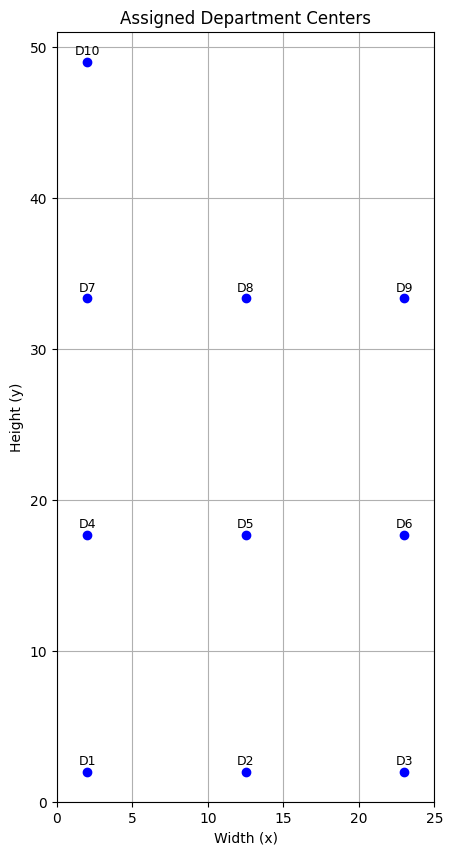

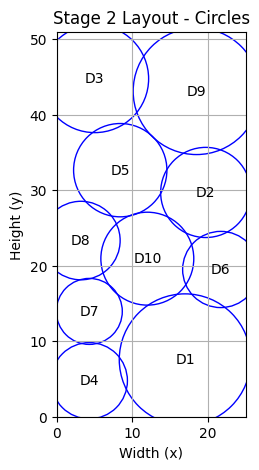

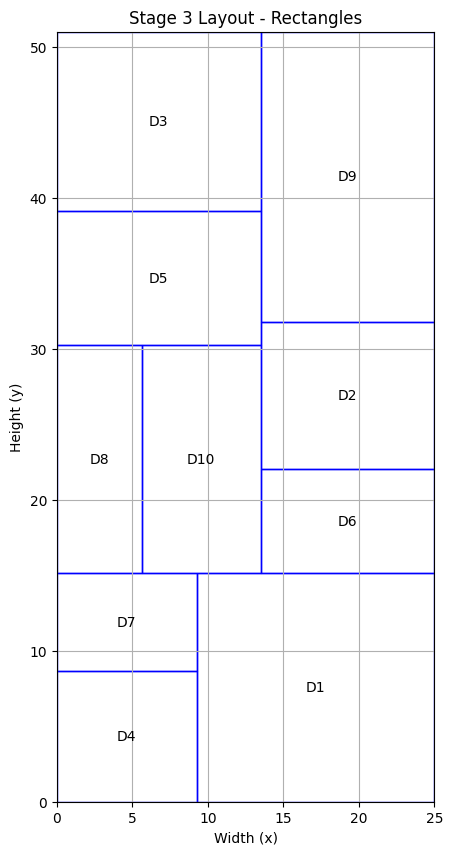

In [ ]:
import numpy as np
import scipy.optimize as opt
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from itertools import combinations


class MomentLayoutOptimizer:
    def __init__(self, n, flow_matrix, cost_vector, facility_width, facility_height):
        self.n = n
        self.flow = flow_matrix
        self.cost = cost_vector
        self.facility_width = facility_width
        self.facility_height = facility_height

    def generate_ideal_layout(self, padding=2.0):
        aspect_ratio = self.facility_width / self.facility_height
        n_cols = int(np.ceil(np.sqrt(self.n * aspect_ratio)))
        n_rows = int(np.ceil(self.n / n_cols))
        x_vals = np.linspace(padding, self.facility_width - padding, n_cols)
        y_vals = np.linspace(padding, self.facility_height - padding, n_rows)
        xv, yv = np.meshgrid(x_vals, y_vals)
        centers = np.column_stack((xv.ravel(), yv.ravel()))
        return centers[:self.n]

    # def assign_departments_by_transport_cost(self, initial_centers):
    #     def objective(x):
    #         coords = x.reshape(self.n, 2)
    #         dists = cdist(coords, coords)
    #         return np.sum(self.flow * dists)

    #     result = opt.minimize(
    #         objective,
    #         initial_centers.flatten(),
    #         method='L-BFGS-B',
    #         bounds=[(0, self.facility_width) if i % 2 == 0 else (0, self.facility_height) for i in range(2 * self.n)],
    #         options={'maxiter': 10000, 'disp': True}
    #     )

    #     return result.x.reshape(self.n, 2)

    def generate_ideal_ellipse_layout(self):

          facility_width = 100
          facility_height = 200
          n = 10  # number of departments

          # Ellipse center (center of facility)
          cx = facility_width / 2
          cy = facility_height / 2

          # Semi-axes of the ellipse (scaled to fit inside the facility)
          a = facility_width * 0.4  # horizontal semi-axis
          b = facility_height * 0.45  # vertical semi-axis

          # Angle for each department on the ellipse
          angles = np.linspace(0, 2 * np.pi, n, endpoint=False)

          # Compute (x, y) centers along the ellipse
          x = cx + a * np.cos(angles)
          y = cy + b * np.sin(angles)
          centers = np.column_stack((x, y))

          return centers

    def get_ideal_moments(self, coords, m=1, N=2):
        coords = coords.reshape(self.n, 2)
        moments = {}
        for order in range(1, N + 1):
            for k in range(0, min(order, m) + 1):
                moments[(order, k)] = np.sum(coords[:, 0] ** (order - k) * coords[:, 1] ** k)
        return moments

    def stage1_objective(self, coords):
        coords = coords.reshape(self.n, 2)
        d2 = np.sum((coords[:, None, :] - coords[None, :, :]) ** 2, axis=2)
        external_d2 = np.sum(coords ** 2, axis=1)
        total_cost = np.sum(self.flow * d2) + np.sum(self.cost * external_d2)
        return total_cost

    def moment_constraints(self, coords, ideal_moments, m=1, N=2):
        coords = coords.reshape(self.n, 2)
        current = self.get_ideal_moments(coords, m, N)
        return [current.get(key, 0) - ideal_moments[key] for key in ideal_moments]

    def solve_stage1_with_moment_constraints(self, initial_coords, ideal_moments, m=1, N=2):
        constraints = {
            'type': 'eq',
            'fun': lambda x: self.moment_constraints(x, ideal_moments, m=m, N=N)
        }
        return opt.minimize(
            self.stage1_objective,
            initial_coords.flatten(),
            constraints=constraints,
            method='SLSQP',
            options={'maxiter': 10000, 'disp': True}
        )

    def stage2_objective(self, coords, radii):
        coords = coords.reshape(self.n, 2)
        d = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=2)
        penalty = 0
        for i in range(self.n):
            for j in range(i + 1, self.n):
                min_dist = radii[i] + radii[j]
                actual_dist = d[i, j]
                if actual_dist < min_dist:
                    penalty += (min_dist - actual_dist) ** 2
        for i in range(self.n):
            x, y, r = coords[i, 0], coords[i, 1], radii[i]
            penalty += max(0, r - x) ** 2
            penalty += max(0, r - y) ** 2
            penalty += max(0, x + r - self.facility_width) ** 2
            penalty += max(0, y + r - self.facility_height) ** 2
            # penalty += max(0, ltmin - radii[i]) ** 2
            # penalty += max(0, radii[i] - ltmax) ** 2
        return np.sum(self.flow * d) + 1e3 * penalty

    def solve_stage2_with_circle_model(self, initial_coords, areas):
        radii = np.sqrt(np.array(areas) / np.pi)
        result = opt.minimize(
            lambda x: self.stage2_objective(x, radii),
            initial_coords.flatten(),
            method='L-BFGS-B',
            options={'maxiter': 10000, 'disp': True}
        )
        return result, radii

    def stage3_objective(self, vars):
        coords = vars[:2*self.n].reshape(self.n, 2)
        widths = vars[2*self.n:3*self.n]
        heights = vars[3*self.n:]
        flow_cost = np.sum(self.flow * cdist(coords, coords))
        penalty_cost = 0
        for i in range(self.n):
            xi, yi = coords[i]
            wi, hi = widths[i], heights[i]
            penalty_cost += max(0, - (xi - wi / 2)) ** 2
            penalty_cost += max(0, - (yi - hi / 2)) ** 2
            penalty_cost += max(0, (xi + wi / 2 - self.facility_width)) ** 2
            penalty_cost += max(0, (yi + hi / 2 - self.facility_height)) ** 2
            for j in range(i + 1, self.n):
                xj, yj = coords[j]
                wj, hj = widths[j], heights[j]
                dx = abs(xi - xj)
                dy = abs(yi - yj)
                wx = 0.5 * (wi + wj)
                hy = 0.5 * (hi + hj)
                if dx < wx and dy < hy:
                    if wx - dx < hy - dy:
                        penalty_cost += (wx - dx) ** 2
                    else:
                        penalty_cost += (hy - dy) ** 2
        return flow_cost + 1e7 * penalty_cost

    def solve_stage3_with_dimension_optimization(self, initial_centers, areas):
        def objective(x):
            coords = x[:2*self.n].reshape(self.n, 2)
            ws = x[2*self.n:3*self.n]
            hs = x[3*self.n:]
            flow_cost = np.sum(self.flow * cdist(coords, coords))
            penalty_cost = 0
            for i in range(self.n):
                xi, yi, wi, hi = coords[i, 0], coords[i, 1], ws[i], hs[i]
                penalty_cost += max(0, - (xi - wi / 2)) ** 2
                penalty_cost += max(0, - (yi - hi / 2)) ** 2
                penalty_cost += max(0, (xi + wi / 2 - self.facility_width)) ** 2
                penalty_cost += max(0, (yi + hi / 2 - self.facility_height)) ** 2
                penalty_cost += (wi * hi - areas[i]) ** 2
                for j in range(i + 1, self.n):
                    xj, yj, wj, hj = coords[j, 0], coords[j, 1], ws[j], hs[j]
                    dx = abs(xi - xj)
                    dy = abs(yi - yj)
                    wx = 0.5 * (wi + wj)
                    hy = 0.5 * (hi + hj)
                    if dx < wx and dy < hy:
                        if wx - dx < hy - dy:
                            penalty_cost += (wx - dx) ** 2
                        else:
                            penalty_cost += (hy - dy) ** 2
            return flow_cost + 1e7 * penalty_cost

        x0 = np.concatenate([
            initial_centers.flatten(),
            np.full(self.n, 10.0),  # Initial width
            np.array([areas[i] / 10.0 for i in range(self.n)])  # Initial height from area/w
        ])

        bounds = [
            (0, self.facility_width) if i % 2 == 0 else (0, self.facility_height)
            for i in range(2 * self.n)  # Bounds for x and y coordinates
              ] + [(5, None)] * (2 * self.n)  # Only minimum bound for widths and heights


        result = opt.minimize(
            objective,
            x0,
            method='L-BFGS-B',
            bounds=bounds,
            options={'maxiter': 10000, 'maxfun': 500000, 'disp': True}
        )
        return result

    def delta_swap_stage1_centers(self, coords, areas, delta=0.1):
        """
        Swap departments with similar areas if it reduces total cost (Stage 1 style).
        """
        coords = coords.copy()
        best_cost = self.stage1_objective(coords.flatten())
        improved = True

        while improved:
            improved = False
            for i, j in combinations(range(self.n), 2):
                ai, aj = areas[i], areas[j]
                if abs(1 - ai / aj) < delta:
                    swapped_coords = coords.copy()
                    swapped_coords[[i, j]] = swapped_coords[[j, i]]
                    cost = self.stage1_objective(swapped_coords.flatten())
                    if cost < best_cost:
                        print(f"Swapping D{i+1} and D{j+1} reduced cost {best_cost:.2f} → {cost:.2f}")
                        coords = swapped_coords
                        best_cost = cost
                        improved = True
                        break  # Optional: restart from scratch after improvement
        return coords


    def plot_department_centers(self, centers, title="Assigned Department Centers"):
        fig, ax = plt.subplots(figsize=(6, 10))
        ax.set_title(title)
        ax.set_xlim(0, self.facility_width)
        ax.set_ylim(0, self.facility_height)
        ax.set_aspect('equal')
        ax.grid(True)

        for i, (x, y) in enumerate(centers):
            ax.plot(x, y, 'bo')  # blue dot for center
            ax.text(x, y + 0.5, f'D{i+1}', ha='center', fontsize=9)

        ax.set_xlabel("Width (x)")
        ax.set_ylabel("Height (y)")
        plt.show()


    def plot_rectangles_variable_size(self, x, title="Stage 3 Layout - Rectangles"):
        coords = x[:2*self.n].reshape(self.n, 2)
        ws = x[2*self.n:3*self.n]
        hs = x[3*self.n:]
        fig, ax = plt.subplots(figsize=(6, 10))
        ax.set_title(title)
        ax.set_xlim(0, self.facility_width)
        ax.set_ylim(0, self.facility_height)
        ax.set_aspect('equal')
        ax.grid(True)
        for i, (x, y) in enumerate(coords):
            w, h = ws[i], hs[i]
            rect = Rectangle((x - w / 2, y - h / 2), w, h, edgecolor='blue', fill=False)
            ax.add_patch(rect)
            ax.text(x, y, f'D{i+1}', ha='center', va='center', fontsize=10)
        ax.set_xlabel("Width (x)")
        ax.set_ylabel("Height (y)")
        plt.show()

    def plot_circles(self, centers, radii, title="Circular Layout"):
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.set_title(title)
        ax.set_xlim(0, self.facility_width)
        ax.set_ylim(0, self.facility_height)
        ax.set_aspect('equal')
        ax.grid(True)
        for i, (x, y) in enumerate(centers):
            ax.add_patch(Circle((x, y), radii[i], edgecolor='blue', fill=False))
            ax.text(x, y, f'D{i+1}', ha='center', va='center')
        ax.set_xlabel("Width (x)")
        ax.set_ylabel("Height (y)")
        plt.show()

if __name__ == "__main__":
    n = 10
    facility_width = 25
    facility_height = 51
    cost_matrix = np.array([
        [0, 0, 0, 0, 0, 218, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 148, 0, 0, 296, 0],
        [0, 0, 0, 28, 70, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 28, 70, 140, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 210, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 28],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 888],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 59.2],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    ])
    cost_vector = np.zeros(n)
    areas = np.array([238, 112, 160, 80, 120, 80, 60, 85, 221, 119])
    ltmin = 25
    ltmax = 25

    ########

    ######
    optimizer = MomentLayoutOptimizer(n, cost_matrix, cost_vector, facility_width, facility_height)
    ideal_grid = optimizer.generate_ideal_layout()
    assigned_centers = ideal_grid
    centers = optimizer.generate_ideal_ellipse_layout()
    ideal_moments = optimizer.get_ideal_moments(assigned_centers, m=1, N=4)



    result1 = optimizer.solve_stage1_with_moment_constraints(centers, ideal_moments, m=1, N=4)
    if not result1.success:
        print("Stage 1 optimization failed", result1.message)
        exit()
    coords1 = result1.x.reshape(n, 2)
    print("Stage 1 Cost:", result1.fun)

    result2, radii = optimizer.solve_stage2_with_circle_model(coords1, areas)
    if not result2.success:
        print("Stage 2 optimization failed", result2.message)
        exit()
    coords2 = result2.x.reshape(n, 2)
    print("Stage 2 Cost:", result2.fun)

    result3 = optimizer.solve_stage3_with_dimension_optimization(coords2, areas)
    if not result3.success:
        print("Stage 3 optimization failed", result3.message)
        exit()
    print("Stage 3 Cost:", result3.fun)

    optimizer.plot_department_centers(assigned_centers)
    optimizer.plot_circles(coords2, radii, title="Stage 2 Layout - Circles")
    optimizer.plot_rectangles_variable_size(result3.x, title="Stage 3 Layout - Rectangles")

[{'n': 10, 'facility_width': 25, 'facility_height': 51, 'cost_matrix': array([[  0. ,   0. ,   0. ,   0. ,   0. , 218. ,   0. ,   0. ,   0. ,
          0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. , 148. ,   0. ,   0. , 296. ,
          0. ],
       [  0. ,   0. ,   0. ,  28. ,  70. ,   0. ,   0. ,   0. ,   0. ,
          0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,  28. ,  70. , 140. ,   0. ,
          0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. , 210. ,   0. ,
          0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
         28. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
        888. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
         59.2],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ]]), 'cost_vector': array([0., 0., 0., 0., 0., 0., 0., 0., 0.,

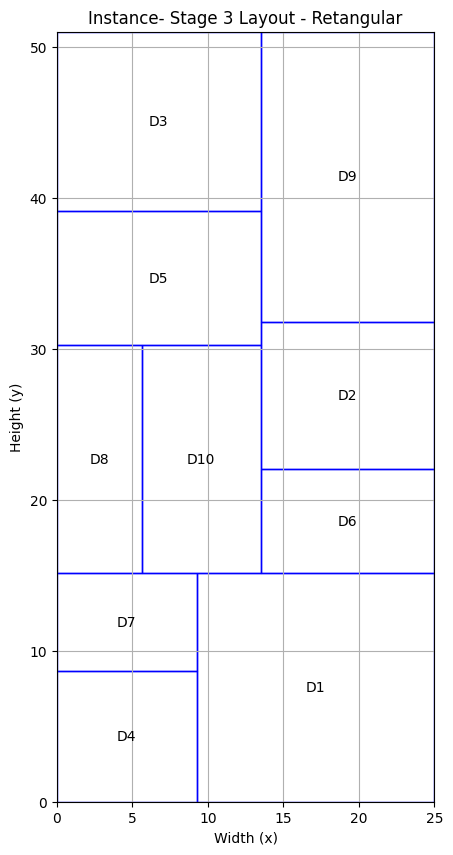


--- Running Instance 2 ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: 5082524.817355743
            Iterations: 1627
            Function evaluations: 37255
            Gradient evaluations: 1627
Instance 2 - Stage 1 Optimization:
  Success: Cost = 5082524.82
Instance 2 - Stage 2 Optimization:
  Success: Cost = 389349.45
Instance 2 - Stage 3 Optimization:
  Success: Cost = 342132.90


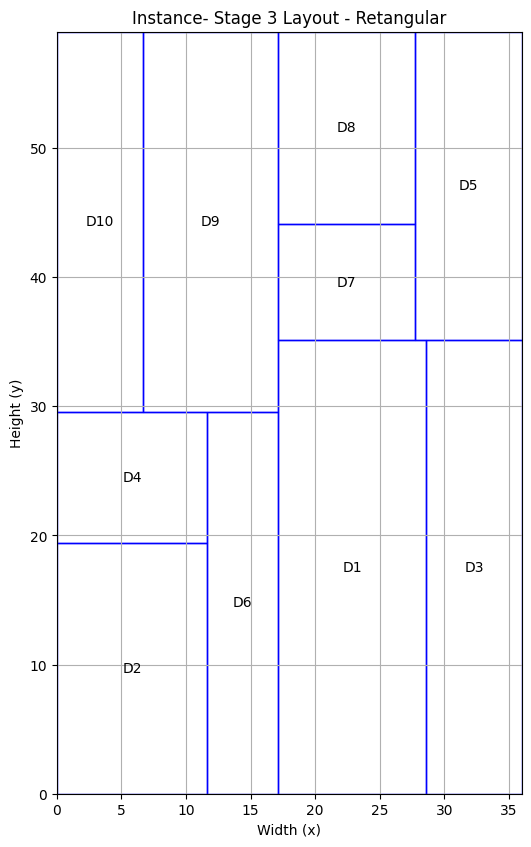


--- Running Instance 3 ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4243338.924915958
            Iterations: 1000
            Function evaluations: 22672
            Gradient evaluations: 1000
Instance 3 - Stage 1 Optimization:
  Success: Cost = 4243338.92
Instance 3 - Stage 2 Optimization:
  Success: Cost = 355563.95
Instance 3 - Stage 3 Optimization:
  Success: Cost = 310869.07


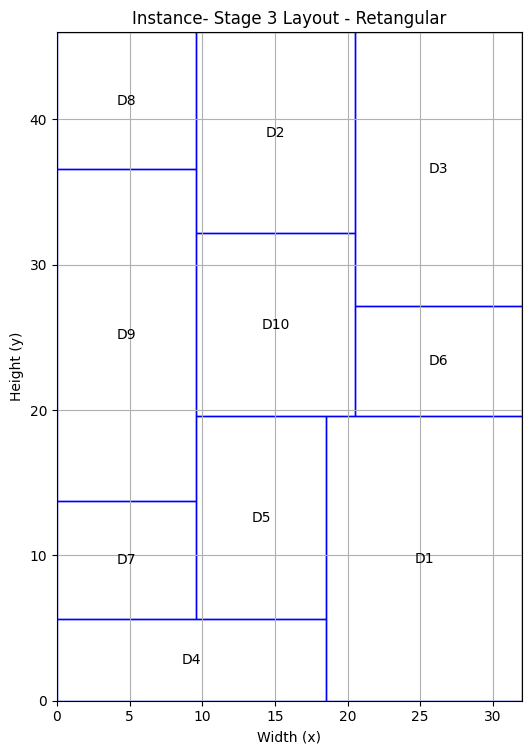


--- Running Instance 4 ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: 11575707.450803898
            Iterations: 306
            Function evaluations: 6945
            Gradient evaluations: 306
Instance 4 - Stage 1 Optimization:
  Success: Cost = 11575707.45
Instance 4 - Stage 2 Optimization:
  Success: Cost = 567356.55
Instance 4 - Stage 3 Optimization:
  Success: Cost = 2844451.98


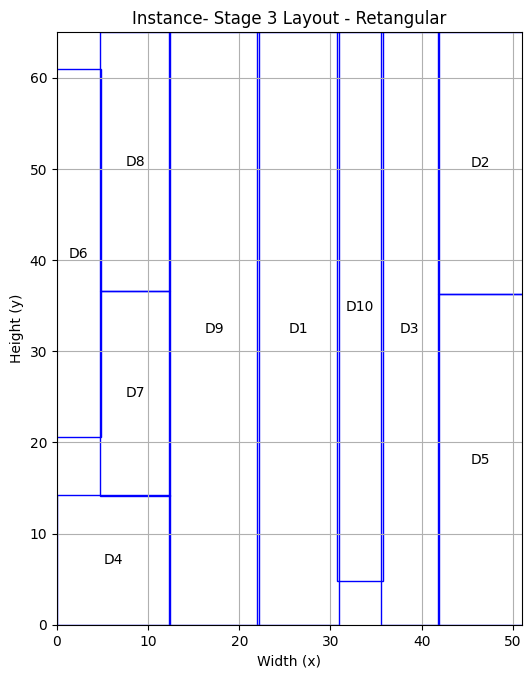


--- Running Instance 5 ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7610895.480954914
            Iterations: 3643
            Function evaluations: 83124
            Gradient evaluations: 3643
Instance 5 - Stage 1 Optimization:
  Success: Cost = 7610895.48
Instance 5 - Stage 2 Optimization:
  Success: Cost = 414842.73
Instance 5 - Stage 3 Optimization:
  Success: Cost = 349835.29


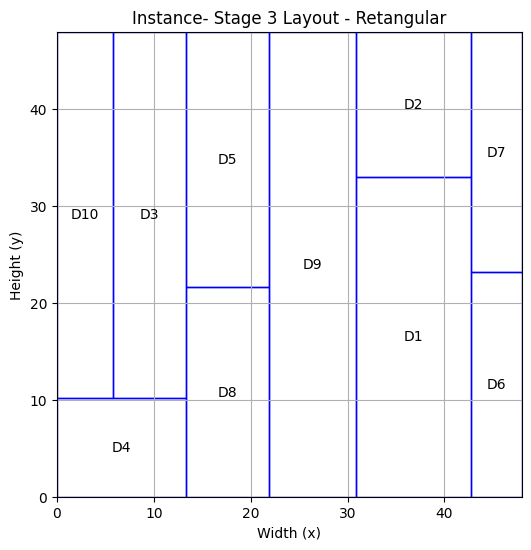


--- Running Instance 6 ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3519762.7638036236
            Iterations: 1934
            Function evaluations: 43958
            Gradient evaluations: 1934
Instance 6 - Stage 1 Optimization:
  Success: Cost = 3519762.76
Instance 6 - Stage 2 Optimization:
  Success: Cost = 356275.87
Instance 6 - Stage 3 Optimization:
  Success: Cost = 575295.75


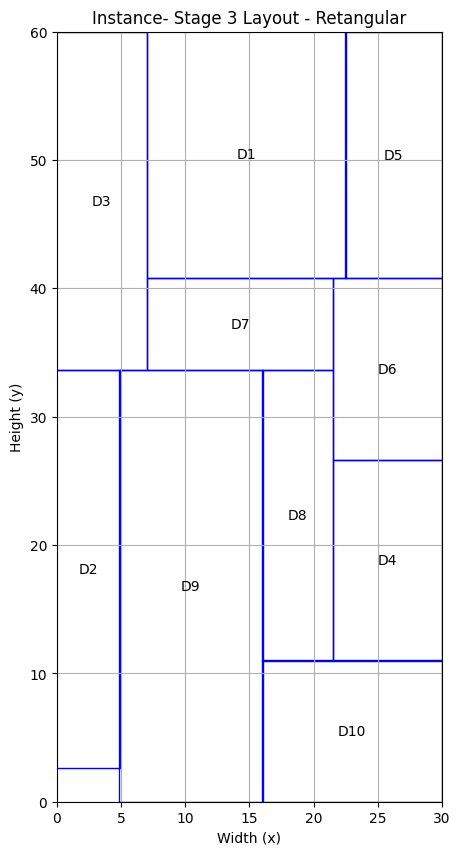

In [ ]:

if __name__ == "__main__":
    np.random.seed(42) # for reproducibility
    facility_area = 25 * 51 # Calculate facility area
    n_original = 10
    original_areas = np.array([238, 112, 160, 80, 120, 80, 60, 85, 221, 119])

    instances = []
    # Instance 1 (provided in the question)
    instances.append({
        'n': 10,
        'facility_width': 25,
        'facility_height': 51,
        'cost_matrix': np.array([
            [0, 0, 0, 0, 0, 218, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 148, 0, 0, 296, 0],
            [0, 0, 0, 28, 70, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 28, 70, 140, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 210, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 28],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 888],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 59.2],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
        ]),
        'cost_vector': np.zeros(10),
        'areas': np.array([238, 112, 160, 80, 120, 80, 60, 85, 221, 119])
    })

    # Generate 9 more similar random instances
    for i in range(5):
        n = n_original
        facility_width = np.random.randint(30, 60)
        facility_height = np.random.randint(40, 70)
        cost_matrix = np.random.randint(0, 300, size=(n, n))
        np.fill_diagonal(cost_matrix, 0)
        # Ensure some non-zero costs similar to the first instance
        for r in range(n):
            for c in range(n):
                if instances[0]['cost_matrix'][r, c] > 0 and np.random.rand() < 0.5:
                    cost_matrix[r, c] = np.random.randint(int(instances[0]['cost_matrix'][r, c] * 0.5), int(instances[0]['cost_matrix'][r, c] * 1.5) + 1)

        cost_vector = np.random.rand(n) * 50
        # Keep areas relatively similar, ensuring the sum equals facility area
        facility_area = facility_width * facility_height
        base_scale = facility_area / np.sum(original_areas)
        areas = original_areas * (0.8 + np.random.rand(n) * 0.4) # Scale around the original areas
        areas = facility_area * areas / np.sum(areas) # Normalize to facility area

        instances.append({
            'n': n,
            'facility_width': facility_width,
            'facility_height': facility_height,
            'cost_matrix': cost_matrix,
            'cost_vector': cost_vector,
            'areas': areas
        })
    print(instances)
    for i, instance in enumerate(instances):
        print(f"\n--- Running Instance {i+1} ---")
        n = instance['n']
        facility_width = instance['facility_width']
        facility_height = instance['facility_height']
        cost_matrix = instance['cost_matrix']
        cost_vector = instance['cost_vector']
        areas = instance['areas']

        optimizer = MomentLayoutOptimizer(n, cost_matrix, cost_vector, facility_width, facility_height)
        ideal_grid = optimizer.generate_ideal_layout()
        assigned_centers = ideal_grid
        centers = optimizer.generate_ideal_ellipse_layout()
        ideal_moments = optimizer.get_ideal_moments(assigned_centers, m=1, N=4)

        result1 = optimizer.solve_stage1_with_moment_constraints(centers, ideal_moments, m=1, N=4)
        print(f"Instance {i+1} - Stage 1 Optimization:")
        if not result1.success:
            print(f"  Failed: {result1.message}")
        else:
            print(f"  Success: Cost = {result1.fun:.2f}")
            coords1 = result1.x.reshape(n, 2)

            result2, radii = optimizer.solve_stage2_with_circle_model(coords1, areas)
            print(f"Instance {i+1} - Stage 2 Optimization:")
            if not result2.success:
                print(f"  Failed: {result2.message}")
            else:
                print(f"  Success: Cost = {result2.fun:.2f}")
                coords2 = result2.x.reshape(n, 2)
                # optimizer.plot_circles(coords2, radii, title=f"Instance {i+1} - Stage 2 Layout - Circles")

                result3 = optimizer.solve_stage3_with_dimension_optimization(coords2, areas)
                print(f"Instance {i+1} - Stage 3 Optimization:")
                if not result3.success:
                    print(f"  Failed: {result3.message}")
                else:
                    print(f"  Success: Cost = {result3.fun:.2f}")
                    optimizer.plot_rectangles_variable_size(result3.x, title=f"Instance- Stage 3 Layout - Retangular")